# **5-2. 차원축소**

In [ ]:
# 라이브러리 불러오기
import pandas as pd

In [ ]:
# 와인 데이터 불러오기
from sklearn.datasets import load_wine
dataset = load_wine()
data = pd.DataFrame(dataset.data, columns=dataset.feature_names)

In [ ]:
# 데이터 샘플 확인
print(data.shape)
data.head()

(178, 13)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [ ]:
# Standard Scalaing
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
data = scaler.fit_transform(data)
data [:3]

array([[ 1.51861254, -0.5622498 ,  0.23205254, -1.16959318,  1.91390522,
         0.80899739,  1.03481896, -0.65956311,  1.22488398,  0.25171685,
         0.36217728,  1.84791957,  1.01300893],
       [ 0.24628963, -0.49941338, -0.82799632, -2.49084714,  0.01814502,
         0.56864766,  0.73362894, -0.82071924, -0.54472099, -0.29332133,
         0.40605066,  1.1134493 ,  0.96524152],
       [ 0.19687903,  0.02123125,  1.10933436, -0.2687382 ,  0.08835836,
         0.80899739,  1.21553297, -0.49840699,  2.13596773,  0.26901965,
         0.31830389,  0.78858745,  1.39514818]])

In [ ]:
# 데이터 복사(df 변수)
df = data.copy()

## PCA

In [ ]:
# 라이브러리 불러오기
from sklearn.decomposition import PCA

In [ ]:
# PCA
pca = PCA(n_components=2)

In [ ]:
# PCA 변환
df = pca.fit_transform(df)
df.shape

(178, 2)

In [ ]:
# 샘플 데이터 확인
df[:3]

array([[ 3.31675081,  1.44346263],
       [ 2.20946492, -0.33339289],
       [ 2.51674015,  1.0311513 ]])

## PCA 시각화(2차원)

In [ ]:
# 시각화 라이브러리
import matplotlib.pyplot as plt

In [ ]:
# 데이터 프레인 전환
df = pd.DataFrame(df)
df.head

<bound method NDFrame.head of             0         1
0    3.316751  1.443463
1    2.209465 -0.333393
2    2.516740  1.031151
3    3.757066  2.756372
4    1.008908  0.869831
..        ...       ...
173 -3.370524  2.216289
174 -2.601956  1.757229
175 -2.677839  2.760899
176 -2.387017  2.297347
177 -3.208758  2.768920

[178 rows x 2 columns]>

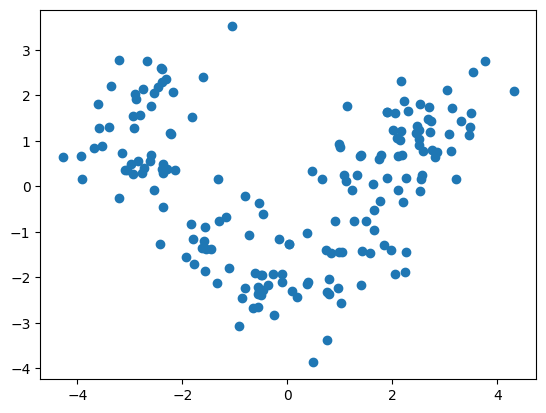

In [ ]:
# scatter
plt.scatter(df.iloc[:, 0], df.iloc[:, 1])

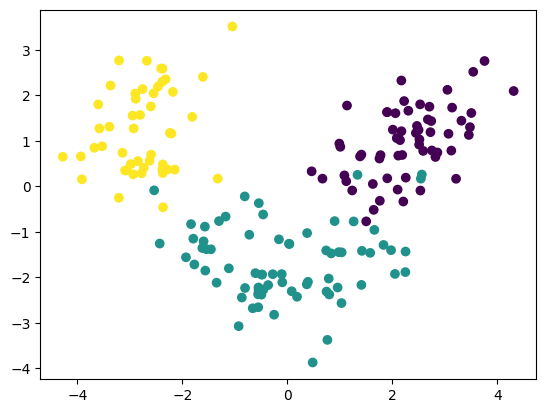

In [ ]:
# scatter
plt.scatter(df.iloc[:, 0], df.iloc[:, 1], c=dataset.target)

In [ ]:
# 데이터 설명(%)
print(pca.explained_variance_ratio_)
print(pca.explained_variance_ratio_.sum())

[0.36198848 0.1920749 ]
0.5540633835693526


## 지도학습(PCA 전후 비교)

In [ ]:
# PCA후 데이터로 머신러닝(2)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

model = RandomForestClassifier(random_state=2022)
cross_val_score(model, df, dataset.target, scoring='accuracy', cv=5).mean()

np.float64(0.9492063492063492)

In [ ]:
# PCA전 데이터로 머신러닝(13)
cross_val_score(model, df, dataset.target, scoring='accuracy', cv=5).mean()

np.float64(0.9492063492063492)

## PCA 시각화(3차원)

In [ ]:
# 새 데이터 복사
df = data.copy()

In [ ]:
# pca (n_components=3)
pca = PCA(n_components=3)

In [ ]:
# pca 변환
df = pca.fit_transform(df)

In [ ]:
# 데이터 프레임 변환
df = pd.DataFrame(df)

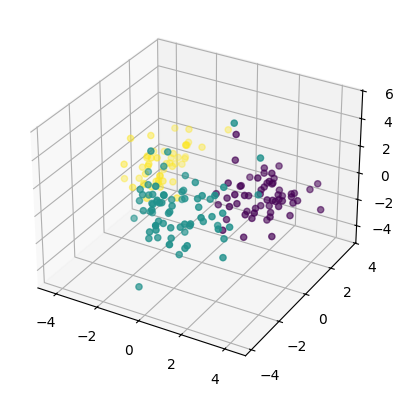

In [ ]:
# 시각화 (3차원)
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df.iloc[:, 0], df.iloc[:, 1], df.iloc[:, 2], c=dataset.target)

## 점진적 PCA
- 데이터셋이 큰 경우 활용(배치를 통해 점진적 수행)

In [ ]:
# 라이브러리 불러오기
from sklearn.decomposition import IncrementalPCA

In [ ]:
# 데이터 복사
df = data.copy()

In [ ]:
# 점진적 PCA
pca = IncrementalPCA(n_components=2, batch_size=16)

In [ ]:
# 점진적 PCA 변환
df = pca.fit_transform(df)

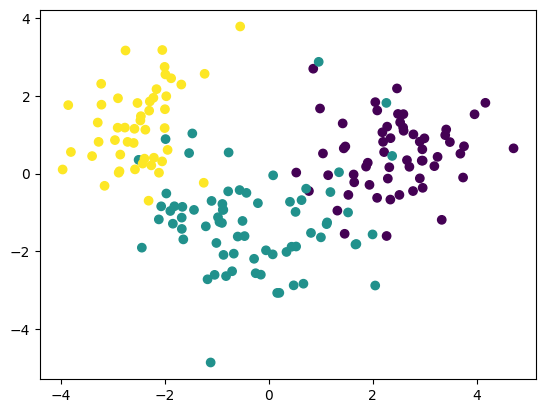

In [ ]:
# 시각화
df = pd.DataFrame(df)
plt.scatter(df.iloc[:, 0], df.iloc[:, 1], c=dataset.target)

In [ ]:
# 데이터 설명(%)
print(pca.explained_variance_ratio_)
print(pca.explained_variance_ratio_.sum())

[0.3400206  0.15239134]
0.4924119400154383


## 희소 PCA
- 적절한 희소성을 유지 (alpha 값으로 조정)
- 오버피팅 방지

In [ ]:
# 라이브러리불러오기
from sklearn.decomposition import SparsePCA

In [ ]:
# 데이터 복사
df = data.copy()

In [ ]:
# 희소 PCA
pca = SparsePCA(n_components=2, alpha=0.01)

In [ ]:
# 희소 PCA 변환
df = pca.fit_transform(df)

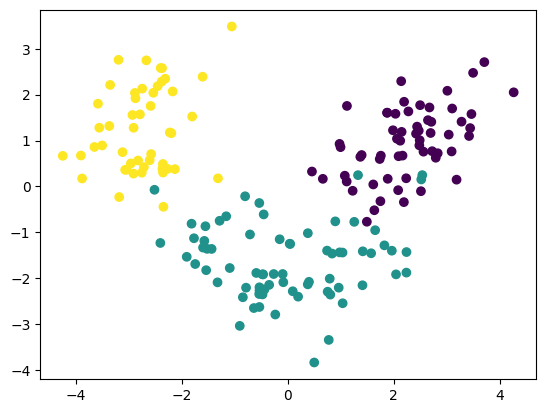

In [ ]:
# 시각화
df = pd.DataFrame(df)
plt.scatter(df.iloc[:, 0], df.iloc[:, 1], c=dataset.target)

## 커널 PCA
- 비선형으로 차원축소

In [ ]:
# 라이브러리불러오기
from sklearn.decomposition import KernelPCA

In [ ]:
# 데이터 복사
df = data.copy()

In [ ]:
# 커널  PCA
pca = KernelPCA(n_components=2)

In [ ]:
# 커널 PCA 변환
df = pca.fit_transform(df)

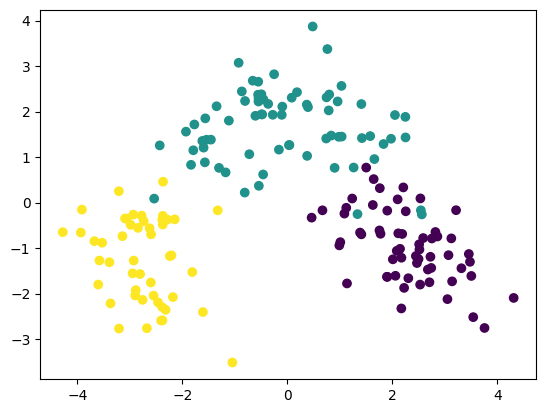

In [ ]:
# 시각화
df = pd.DataFrame(df)
plt.scatter(df.iloc[:, 0], df.iloc[:, 1], c=dataset.target)

## SVD(Single Vlaue Decomposition) 특이값 분해
- 행렬을 특정한 구조로 분해하는 방식
- 신호처리, 통계학 등의 분야에서 자주 사용됨

In [ ]:
# 라이브러리불러오기
from sklearn.decomposition import TruncatedSVD

In [ ]:
# 데이터 복사
df = data.copy()

In [ ]:
# SVD 적용
pca = TruncatedSVD(n_components=2)

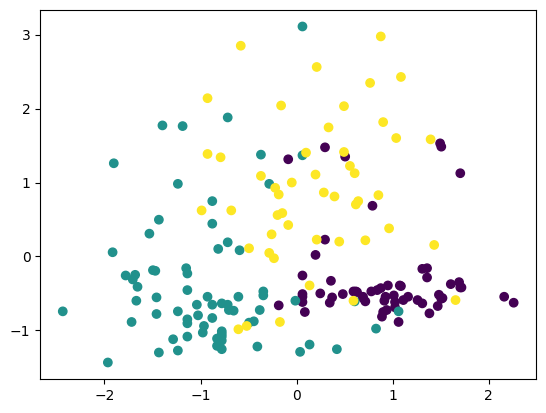

In [ ]:
# 시각화
df = pd.DataFrame(df)
plt.scatter(df.iloc[:, 0], df.iloc[:, 1], c=dataset.target)

# **5-3. 군집(클러스터링)**

In [ ]:
# KMeans 라이브러리
from sklearn.cluster import KMeans

# 와인 데이터 불러오기
from sklearn.datasets import load_wine
dataset = load_wine()
data = pd.DataFrame(dataset.data, columns=dataset.feature_names)
df = data.copy()

## 비계층적 군집분석
- 임의의 지점 K개를 선택해 해당 중심에서 가꺼운 데이터를 군집화
- **n_clusters** 하이퍼파라미터 반드시 설정해야함

In [ ]:
# KMeans 선언 및 학습
kmeans = KMeans(n_clusters=3)
kmeans.fit(df)

KMeans(n_clusters=3)

In [ ]:
# KMeans 예측
pred = kmeans.predict(df)

In [ ]:
# 실제 - 예측 비교
df['target'] = dataset.target
df['pred'] = pred
df

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,pred
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,2
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,2
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,1
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,1
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2,2


### PCA -> 군집 -> 시각화

In [ ]:
# PCA
df = data.copy()
pca = PCA(n_components=2)
df = pca.fit_transform(df)
df = pd.DataFrame(df)
df.head()

,0,1
0,318.562979,21.492131
1,303.097420,-5.364718
2,438.061133,-6.537309
3,733.240139,0.192729
4,-11.571428,18.489995


In [ ]:
# kmeans
kmeans = KMeans(n_clusters=3)
kmeans.fit(df)
pred = kmeans.predict(df)
df['kmeans'] = pred
df

,0,1,kmeans
0,318.562979,21.492131,1
1,303.097420,-5.364718,1
2,438.061133,-6.537309,1
3,733.240139,0.192729,1
4,-11.571428,18.489995,2
...,...,...,...
173,-6.980211,-4.541137,2
174,3.131605,2.335191,2
175,88.458074,18.776285,2
176,93.456242,18.670819,2


In [ ]:
# 각 군집의 중심점
centers = kmeans.cluster_centers_

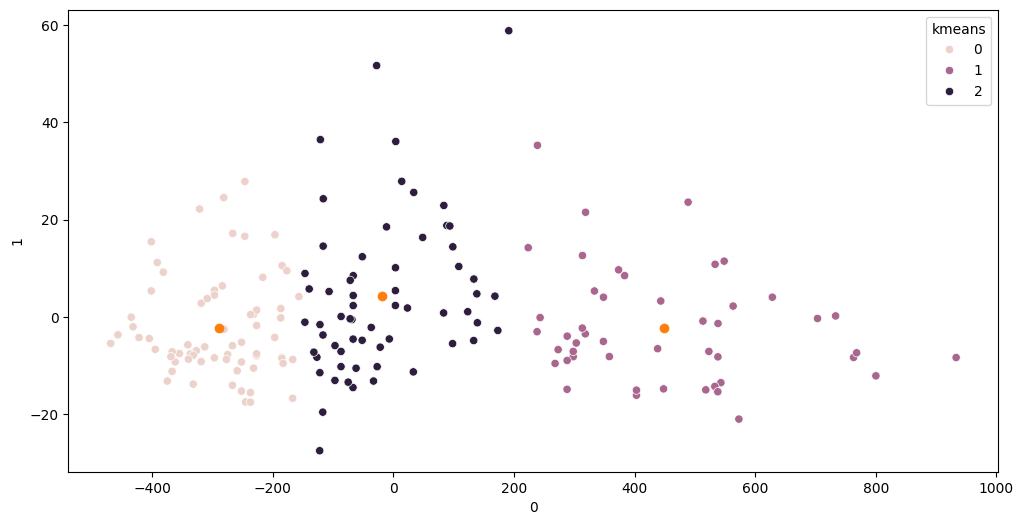

In [ ]:
# 시각화
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.scatterplot(x=df.iloc[:, 0], y=df.iloc[:, 1], hue=df['kmeans'])
plt.scatter(centers[:, 0], centers[:, 1])

### 군집수 찾는법 (elbow methiod)

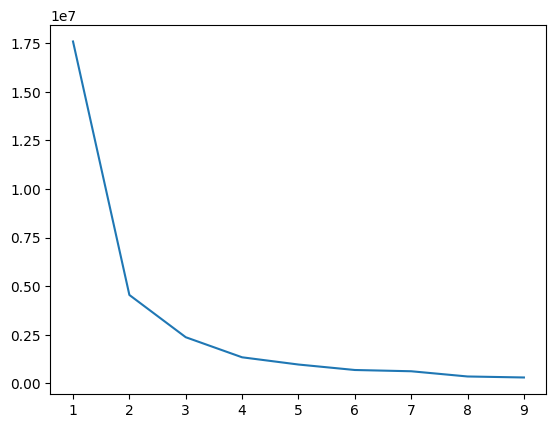

In [ ]:
# 군집수 찾기
df.columns = df.columns.astype(str)

inertia = []
for i in range (1, 10):
  kmeans = KMeans(n_clusters=i, random_state=2022)
  kmeans.fit(df)
  inertia.append(kmeans.inertia_)

plt.plot(range(1,10), inertia)

## 계층적 군집분석
- k-means와 달리 군집 개수를 사전에 설정하지 않음
- 덴드로 그램 사용

In [ ]:
# 덴드로그램 라이브러리
from scipy.cluster.hierarchy import dendrogram, ward

In [ ]:
# PCA
df = data.copy()
pca = PCA(n_components=2)
df = pca.fit_transform(df)
df = pd.DataFrame(df)

In [ ]:
# 샘플링
# append() 메서드는 pandas 2.0 이상에서 제거(deprecated) 됨
# kdata = df[:3].copy()
# kdata = kdata.append(df[70:73])
# kdata = kdata.append(df[160:163])
# kdata

kdata = df[:3].copy()
kdata = pd.concat([kdata, df[70:73], df[160:163]], ignore_index=False)
kdata

,0,1
0,318.562979,21.492131
1,303.097420,-5.364718
2,438.061133,-6.537309
70,123.130138,1.059835
71,-337.104122,-7.623855
72,-275.096026,-7.753152
160,-227.068836,-7.618630
161,-66.755431,8.470290
162,-176.765098,9.473190


{'icoord': [[15.0, 15.0, 25.0, 25.0],
  [5.0, 5.0, 20.0, 20.0],
  [55.0, 55.0, 65.0, 65.0],
  [45.0, 45.0, 60.0, 60.0],
  [35.0, 35.0, 52.5, 52.5],
  [75.0, 75.0, 85.0, 85.0],
  [43.75, 43.75, 80.0, 80.0],
  [12.5, 12.5, 61.875, 61.875]],
 'dcoord': [[0.0,
   np.float64(30.991512411471586),
   np.float64(30.991512411471586),
   0.0],
  [0.0,
   np.float64(147.87787795984812),
   np.float64(147.87787795984812),
   np.float64(30.991512411471586)],
  [0.0, np.float64(48.02737852215064), np.float64(48.02737852215064), 0.0],
  [0.0,
   np.float64(88.07194000276085),
   np.float64(88.07194000276085),
   np.float64(48.02737852215064)],
  [0.0,
   np.float64(135.87135248973354),
   np.float64(135.87135248973354),
   np.float64(88.07194000276085)],
  [0.0, np.float64(190.03011431770938), np.float64(190.03011431770938), 0.0],
  [np.float64(135.87135248973354),
   np.float64(461.01587369114725),
   np.float64(461.01587369114725),
   np.float64(190.03011431770938)],
  [np.float64(147.8778779598481

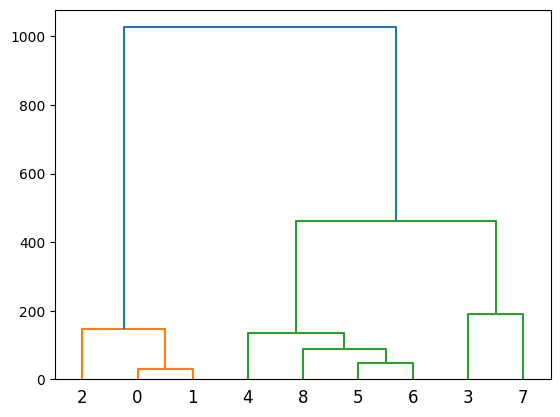

In [ ]:
# 덴드로그램
linkage = ward(kdata)
dendrogram(linkage)